---
# Comparaison V1 (FMA officiel) vs V2 (Maison)
## LogisticRegression + Linear SVC + RandomForest — conditions strictement identiques
---

**Objectif** : déterminer si les features V2 (maison) sont comparables à V1 (FMA officiel)  
sur les mêmes modèles, le même split, les mêmes métriques.

| Paramètre | Valeur |
|---|---|
| Split | GroupShuffleSplit par `artist_name`, test_size=0.2, seed=42 |
| Modèles | LogisticRegression + RandomForest |
| Métrique principale | macro F1 |
| Métrique secondaire | accuracy |
| Scaling | StandardScaler fit sur train uniquement |
| Imputation | SimpleImputer(median) fit sur train uniquement |


In [1]:
# C1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import time
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    f1_score, accuracy_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

SEED = 42
np.random.seed(SEED)
print('Imports OK ✅')

Imports OK ✅


In [2]:
# C2 — Chemins
PATH_V1 = Path(r'C:\Users\maison\Desktop\DU SDA\MACHINE LEARNING 2\PROJET\outputs\features.csv')
PATH_V2 = Path(r'C:\Users\maison\Desktop\DU SDA\MACHINE LEARNING 2\PROJET\outputs\features\features_V2.csv')
PATH_TRACKS = Path(r'C:\Users\maison\Desktop\DU SDA\MACHINE LEARNING 2\PROJET\data\raw\fma_metadata\tracks.csv')

assert PATH_V1.exists(),     f'V1 introuvable : {PATH_V1}'
assert PATH_V2.exists(),     f'V2 introuvable : {PATH_V2}'
assert PATH_TRACKS.exists(), f'tracks.csv introuvable : {PATH_TRACKS}'
print('Chemins OK ✅')

Chemins OK ✅


In [3]:
# C3 — Chargement V2 (simple — features + labels déjà joints)
print('Chargement V2...')
df_v2 = pd.read_csv(PATH_V2)
df_v2 = df_v2.loc[:, ~df_v2.columns.astype(str).str.startswith('Unnamed:')]

LABEL_COLS = ['track_id', 'genre_top', 'genres', 'genres_decoded', 'n_subgenres',
              'mismatch', 'artist_name', 'track_title', 'year', 'duration', 'bit_rate']
FEATURE_COLS_V2 = [c for c in df_v2.columns if c not in LABEL_COLS]

print(f'V2 shape        : {df_v2.shape}')
print(f'V2 features     : {len(FEATURE_COLS_V2)}')
print(f'V2 NaN features : {df_v2[FEATURE_COLS_V2].isnull().sum().sum()}')
print(f'V2 genres       : {df_v2["genre_top"].value_counts().to_dict()}')

Chargement V2...
V2 shape        : (7994, 362)
V2 features     : 351
V2 NaN features : 104
V2 genres       : {'Pop': 1000, 'Folk': 1000, 'Instrumental': 1000, 'International': 1000, 'Rock': 999, 'Experimental': 999, 'Electronic': 999, 'Hip-Hop': 997}


In [4]:
# C4 — Chargement V1 (header multi-niveaux + filtre Small + jointure labels)
print('Chargement V1 (peut prendre 15-20s)...')
t0 = time.time()

# Chargement features FMA (header sur 3 niveaux)
fma_raw = pd.read_csv(PATH_V1, index_col=0, header=[0, 1, 2])

# Chargement tracks.csv pour labels + filtre Small
tracks = pd.read_csv(PATH_TRACKS, index_col=0, header=[0, 1])
small_tracks = tracks[tracks[('set', 'subset')] == 'small']
small_ids    = small_tracks.index.astype(int)

# Filtre Small sur V1
fma_small = fma_raw.loc[fma_raw.index.intersection(small_ids)].copy()

# Aplatissement colonnes multi-niveaux
fma_small.columns = ['_'.join(filter(None, map(str, col))).strip()
                     for col in fma_small.columns]
fma_small.index.name = 'track_id'
fma_small = fma_small.reset_index()
fma_small['track_id'] = fma_small['track_id'].astype(int)

# Construction labels depuis tracks.csv
labels = pd.DataFrame({
    'track_id'    : small_tracks.index.astype(int),
    'genre_top'   : small_tracks[('track', 'genre_top')].values,
    'artist_name' : small_tracks[('artist', 'name')].values,
})

# Jointure features + labels
df_v1 = fma_small.merge(labels, on='track_id', how='inner')
df_v1 = df_v1.dropna(subset=['genre_top', 'artist_name'])

FEATURE_COLS_V1 = [c for c in df_v1.columns
                   if c not in ['track_id', 'genre_top', 'artist_name']]

print(f'Chargé en {time.time()-t0:.1f}s')
print(f'V1 shape        : {df_v1.shape}')
print(f'V1 features     : {len(FEATURE_COLS_V1)}')
print(f'V1 NaN features : {df_v1[FEATURE_COLS_V1].isnull().sum().sum()}')
print(f'V1 genres       : {df_v1["genre_top"].value_counts().to_dict()}')

Chargement V1 (peut prendre 15-20s)...
Chargé en 27.5s
V1 shape        : (8000, 521)
V1 features     : 518
V1 NaN features : 0
V1 genres       : {'Hip-Hop': 1000, 'Pop': 1000, 'Folk': 1000, 'Experimental': 1000, 'Rock': 1000, 'International': 1000, 'Electronic': 1000, 'Instrumental': 1000}


In [5]:
# C5 — Fonction d'entraînement et évaluation (identique pour V1 et V2)

def run_pipeline(df, feature_cols, label='dataset'):
    """
    Pipeline complet : split → imputation → scaling → modèles → métriques
    Retourne un dict de résultats.
    """
    print(f'\n{"="*55}')
    print(f'PIPELINE : {label} ({len(feature_cols)} features)')
    print(f'{"="*55}')

    X      = df[feature_cols].astype(float).values
    y      = df['genre_top'].values
    groups = df['artist_name'].values

    # --- Split ---
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))

    X_train_raw, X_test_raw = X[train_idx], X[test_idx]
    y_train,     y_test     = y[train_idx], y[test_idx]

    # Vérification aucun artiste commun
    overlap = set(groups[train_idx]) & set(groups[test_idx])
    assert len(overlap) == 0, f'Overlap artistes détecté : {overlap}'

    print(f'Train : {len(y_train)} pistes | Test : {len(y_test)} pistes')
    print(f'Artistes communs train/test : {len(overlap)} ✅')

    # --- Imputation médiane (fit sur train uniquement) ---
    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train_raw)
    X_test_imp  = imputer.transform(X_test_raw)

    # --- Scaling (fit sur train uniquement) ---
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_imp)
    X_test  = scaler.transform(X_test_imp)

    results = {}

    # --- Logistic Regression ---
    print('\nLogisticRegression...')
    t0 = time.time()
    lr = LogisticRegression(
        C=1.0, max_iter=2000, solver='lbfgs',
        class_weight='balanced',
        random_state=SEED
    )
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    f1_lr  = f1_score(y_test, y_pred_lr, average='macro')
    acc_lr = accuracy_score(y_test, y_pred_lr)
    print(f'  F1 macro : {f1_lr:.4f} | Accuracy : {acc_lr:.4f} | {time.time()-t0:.1f}s')
    print(classification_report(y_test, y_pred_lr))
    results['lr'] = {'f1': f1_lr, 'acc': acc_lr, 'pred': y_pred_lr}

    # --- Random Forest ---
    print('RandomForest...')
    t0 = time.time()
    rf = RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        class_weight='balanced', random_state=SEED, n_jobs=-1
    )
    rf.fit(X_train, y_train)  # RF sur données scalées pour cohérence
    y_pred_rf = rf.predict(X_test)
    f1_rf  = f1_score(y_test, y_pred_rf, average='macro')
    acc_rf = accuracy_score(y_test, y_pred_rf)
    print(f'  F1 macro : {f1_rf:.4f} | Accuracy : {acc_rf:.4f} | {time.time()-t0:.1f}s')
    print(classification_report(y_test, y_pred_rf))
    results['rf'] = {'f1': f1_rf, 'acc': acc_rf, 'pred': y_pred_rf,
                     'importances': rf.feature_importances_}

    # --- LinearSVC ---
    from sklearn.svm import LinearSVC
    from sklearn.calibration import CalibratedClassifierCV

    print('LinearSVC...')
    t0 = time.time()
    svc = CalibratedClassifierCV(
        LinearSVC(
            C=1.0, max_iter=2000,
            tol=1e-3,
            class_weight='balanced',
            dual='auto', random_state=SEED
        )
    )
    svc.fit(X_train, y_train)
    y_pred_svc = svc.predict(X_test)
    f1_svc  = f1_score(y_test, y_pred_svc, average='macro')
    acc_svc = accuracy_score(y_test, y_pred_svc)
    print(f'  F1 macro : {f1_svc:.4f} | Accuracy : {acc_svc:.4f} | {time.time()-t0:.1f}s')
    print(classification_report(y_test, y_pred_svc))
    results['svc'] = {'f1': f1_svc, 'acc': acc_svc, 'pred': y_pred_svc}
    
    results['y_test']       = y_test
    results['feature_cols'] = feature_cols
    return results
print('Fonction run_pipeline() chargée ✅')

Fonction run_pipeline() chargée ✅


In [6]:
# C6 — Lancement V2
res_v2 = run_pipeline(df_v2, FEATURE_COLS_V2, label='V2 Maison')


PIPELINE : V2 Maison (351 features)
Train : 6477 pistes | Test : 1517 pistes
Artistes communs train/test : 0 ✅

LogisticRegression...
  F1 macro : 0.4519 | Accuracy : 0.4667 | 4.7s
               precision    recall  f1-score   support

   Electronic       0.47      0.55      0.51       249
 Experimental       0.45      0.37      0.40       199
         Folk       0.39      0.49      0.43       119
      Hip-Hop       0.61      0.53      0.57       233
 Instrumental       0.38      0.42      0.40       170
International       0.57      0.48      0.52       249
          Pop       0.23      0.26      0.25       128
         Rock       0.53      0.54      0.53       170

     accuracy                           0.47      1517
    macro avg       0.45      0.45      0.45      1517
 weighted avg       0.48      0.47      0.47      1517

RandomForest...
  F1 macro : 0.4686 | Accuracy : 0.4779 | 15.6s
               precision    recall  f1-score   support

   Electronic       0.47      0.51 

In [7]:
# C7 — Lancement V1
res_v1 = run_pipeline(df_v1, FEATURE_COLS_V1, label='V1 FMA')


PIPELINE : V1 FMA (518 features)
Train : 6194 pistes | Test : 1806 pistes
Artistes communs train/test : 0 ✅

LogisticRegression...
  F1 macro : 0.4519 | Accuracy : 0.4590 | 3.4s
               precision    recall  f1-score   support

   Electronic       0.53      0.53      0.53       253
 Experimental       0.30      0.42      0.35       187
         Folk       0.45      0.35      0.40       226
      Hip-Hop       0.61      0.64      0.62       236
 Instrumental       0.47      0.42      0.44       249
International       0.56      0.49      0.52       258
          Pop       0.22      0.19      0.21       212
         Rock       0.48      0.62      0.54       185

     accuracy                           0.46      1806
    macro avg       0.45      0.46      0.45      1806
 weighted avg       0.46      0.46      0.46      1806

RandomForest...
  F1 macro : 0.4706 | Accuracy : 0.4779 | 17.1s
               precision    recall  f1-score   support

   Electronic       0.50      0.50    

c:\Users\maison\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\maison\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  F1 macro : 0.4414 | Accuracy : 0.4618 | 1378.6s
               precision    recall  f1-score   support

   Electronic       0.52      0.49      0.51       253
 Experimental       0.29      0.29      0.29       187
         Folk       0.44      0.41      0.42       226
      Hip-Hop       0.55      0.67      0.60       236
 Instrumental       0.48      0.45      0.47       249
International       0.55      0.50      0.53       258
          Pop       0.22      0.11      0.15       212
         Rock       0.46      0.74      0.56       185

     accuracy                           0.46      1806
    macro avg       0.44      0.46      0.44      1806
 weighted avg       0.45      0.46      0.45      1806



In [8]:
# C8 — Tableau comparatif final

print('\n' + '='*55)
print('TABLEAU COMPARATIF V1 vs V2')
print('='*55)

comparatif = pd.DataFrame([
    {'Dataset': 'V2 Maison', 'Modèle': 'LogisticRegression',
     'F1 macro': round(res_v2['lr']['f1'], 4),
     'Accuracy': round(res_v2['lr']['acc'], 4)},
    {'Dataset': 'V2 Maison', 'Modèle': 'RandomForest',
     'F1 macro': round(res_v2['rf']['f1'], 4),
     'Accuracy': round(res_v2['rf']['acc'], 4)},
    {'Dataset': 'V1 FMA',    'Modèle': 'LogisticRegression',
     'F1 macro': round(res_v1['lr']['f1'], 4),
     'Accuracy': round(res_v1['lr']['acc'], 4)},
    {'Dataset': 'V1 FMA',    'Modèle': 'RandomForest',
     'F1 macro': round(res_v1['rf']['f1'], 4),
     'Accuracy': round(res_v1['rf']['acc'], 4)},
     {'Dataset': 'V2 Maison', 'Modèle': 'LinearSVC',
    'F1 macro': round(res_v2['svc']['f1'], 4),
    'Accuracy': round(res_v2['svc']['acc'], 4)},
    {'Dataset': 'V1 FMA',    'Modèle': 'LinearSVC',
    'F1 macro': round(res_v1['svc']['f1'], 4),
    'Accuracy': round(res_v1['svc']['acc'], 4)},
])

print(comparatif.to_string(index=False))

# Écarts V1 - V2
print('\n--- Écarts V1 - V2 ---')
for modele in ['LogisticRegression', 'RandomForest']:
    f1_v1 = comparatif[(comparatif['Dataset']=='V1 FMA') &
                       (comparatif['Modèle']==modele)]['F1 macro'].values[0]
    f1_v2 = comparatif[(comparatif['Dataset']=='V2 Maison') &
                       (comparatif['Modèle']==modele)]['F1 macro'].values[0]
    diff  = round(f1_v1 - f1_v2, 4)
    gagne = 'V1' if diff > 0 else 'V2' if diff < 0 else 'Égalité'
    print(f'  {modele:<22} : V1={f1_v1} | V2={f1_v2} | diff={diff:+.4f} → {gagne}')


TABLEAU COMPARATIF V1 vs V2
  Dataset             Modèle  F1 macro  Accuracy
V2 Maison LogisticRegression    0.4519    0.4667
V2 Maison       RandomForest    0.4686    0.4779
   V1 FMA LogisticRegression    0.4519    0.4590
   V1 FMA       RandomForest    0.4706    0.4779
V2 Maison          LinearSVC    0.4266    0.4555
   V1 FMA          LinearSVC    0.4414    0.4618

--- Écarts V1 - V2 ---
  LogisticRegression     : V1=0.4519 | V2=0.4519 | diff=+0.0000 → Égalité
  RandomForest           : V1=0.4706 | V2=0.4686 | diff=+0.0020 → V1


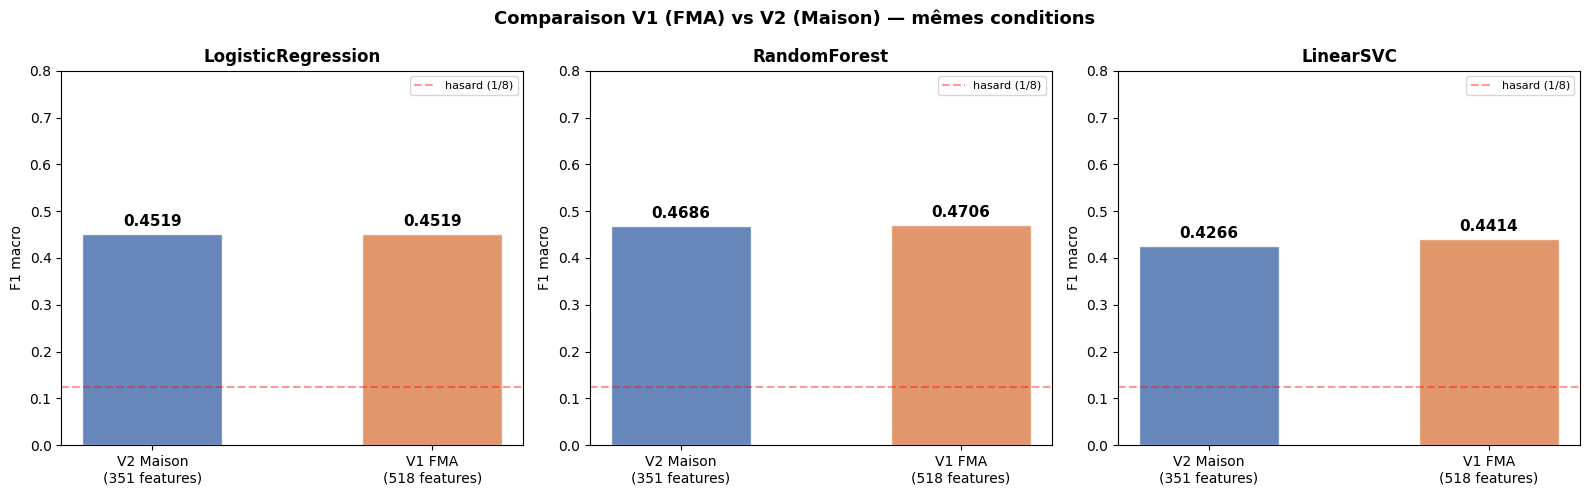

Graphique sauvegardé : comparaison_V1_V2.png


In [10]:
# C9 — Visualisation comparative F1 macro par modèle

fig, axes = plt.subplots(1, 3, figsize=(16, 5))  # ← 1,2 → 1,3

for ax, modele, key in zip(axes,
    ['LogisticRegression', 'RandomForest', 'LinearSVC'],
    ['lr', 'rf', 'svc']):

    # Vérifier que la clé existe dans les deux résultats
    if key not in res_v2 or key not in res_v1:
        ax.set_title(f'{modele}\n(données manquantes)', fontsize=11)
        continue

    vals   = [res_v2[key]['f1'], res_v1[key]['f1']]
    labels = ['V2 Maison\n(351 features)', 'V1 FMA\n(518 features)']
    colors = ['#4C72B0', '#DD8452']

    bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor='white', width=0.5)
    ax.set_ylim(0, 0.8)
    ax.set_title(modele, fontsize=12, fontweight='bold')
    ax.set_ylabel('F1 macro')
    ax.axhline(y=0.125, color='red', linestyle='--', alpha=0.4, label='hasard (1/8)')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Comparaison V1 (FMA) vs V2 (Maison) — mêmes conditions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparaison_V1_V2.png', dpi=120, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : comparaison_V1_V2.png')

In [11]:
# C8 — Tableau comparatif final

print('\n' + '='*55)
print('TABLEAU COMPARATIF V1 vs V2')
print('='*55)

comparatif = pd.DataFrame([
    {'Dataset': 'V2 Maison', 'Modèle': 'LogisticRegression',
     'F1 macro': round(res_v2['lr']['f1'], 4),
     'Accuracy': round(res_v2['lr']['acc'], 4)},
    {'Dataset': 'V2 Maison', 'Modèle': 'RandomForest',
     'F1 macro': round(res_v2['rf']['f1'], 4),
     'Accuracy': round(res_v2['rf']['acc'], 4)},
    {'Dataset': 'V2 Maison', 'Modèle': 'LinearSVC',
     'F1 macro': round(res_v2['svc']['f1'], 4),
     'Accuracy': round(res_v2['svc']['acc'], 4)},
    {'Dataset': 'V1 FMA',    'Modèle': 'LogisticRegression',
     'F1 macro': round(res_v1['lr']['f1'], 4),
     'Accuracy': round(res_v1['lr']['acc'], 4)},
    {'Dataset': 'V1 FMA',    'Modèle': 'RandomForest',
     'F1 macro': round(res_v1['rf']['f1'], 4),
     'Accuracy': round(res_v1['rf']['acc'], 4)},
    {'Dataset': 'V1 FMA',    'Modèle': 'LinearSVC',
     'F1 macro': round(res_v1['svc']['f1'], 4),
     'Accuracy': round(res_v1['svc']['acc'], 4)},
])

print(comparatif.to_string(index=False))

# Écarts V1 - V2
print('\n--- Écarts V1 - V2 ---')
for modele in ['LogisticRegression', 'RandomForest', 'LinearSVC']:
    f1_v1 = comparatif[(comparatif['Dataset']=='V1 FMA') &
                       (comparatif['Modèle']==modele)]['F1 macro'].values[0]
    f1_v2 = comparatif[(comparatif['Dataset']=='V2 Maison') &
                       (comparatif['Modèle']==modele)]['F1 macro'].values[0]
    diff  = round(f1_v1 - f1_v2, 4)
    gagne = 'V1' if diff > 0 else 'V2' if diff < 0 else 'Égalité'
    print(f'  {modele:<22} : V1={f1_v1} | V2={f1_v2} | diff={diff:+.4f} → {gagne}')


TABLEAU COMPARATIF V1 vs V2
  Dataset             Modèle  F1 macro  Accuracy
V2 Maison LogisticRegression    0.4519    0.4667
V2 Maison       RandomForest    0.4686    0.4779
V2 Maison          LinearSVC    0.4266    0.4555
   V1 FMA LogisticRegression    0.4519    0.4590
   V1 FMA       RandomForest    0.4706    0.4779
   V1 FMA          LinearSVC    0.4414    0.4618

--- Écarts V1 - V2 ---
  LogisticRegression     : V1=0.4519 | V2=0.4519 | diff=+0.0000 → Égalité
  RandomForest           : V1=0.4706 | V2=0.4686 | diff=+0.0020 → V1
  LinearSVC              : V1=0.4414 | V2=0.4266 | diff=+0.0148 → V1
